In [1]:
library(ggplot2)
library(dplyr)
library(corrplot)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



In [5]:
data <- read.csv("IBM.csv")

In [6]:
head(data)
tail(data)

,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1,41,Yes,Sales,1,2,Life Sciences,2,4,Single,5993,8,1,6
2,49,No,Research & Development,8,1,Life Sciences,3,2,Married,5130,1,3,10
3,37,Yes,Research & Development,2,2,Other,4,3,Single,2090,6,3,0
4,33,No,Research & Development,3,4,Life Sciences,4,3,Married,2909,1,3,8
5,27,No,Research & Development,2,1,Medical,1,2,Married,3468,9,3,2
6,32,No,Research & Development,2,2,Life Sciences,4,4,Single,3068,0,2,7


,Age,Attrition,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,WorkLifeBalance,YearsAtCompany
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>
1465,26,No,Sales,5,3,Other,4,3,Single,2966,0,3,4
1466,36,No,Research & Development,23,2,Medical,3,4,Married,2571,4,3,5
1467,39,No,Research & Development,6,1,Medical,4,1,Married,9991,4,3,7
1468,27,No,Research & Development,4,3,Life Sciences,2,2,Married,6142,1,3,6
1469,49,No,Sales,2,3,Medical,4,2,Married,5390,2,2,9
1470,34,No,Research & Development,8,3,Medical,2,3,Married,4404,2,4,4


In [7]:
dim(data)
str(data)
summary(data)

[1] 1470   13

'data.frame':	1470 obs. of  13 variables:
 $ Age                    : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition              : chr  "Yes" "No" "Yes" "No" ...
 $ Department             : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome       : int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education              : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField         : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EnvironmentSatisfaction: int  2 3 4 4 1 4 3 4 4 3 ...
 $ JobSatisfaction        : int  4 2 3 3 2 4 1 3 3 3 ...
 $ MaritalStatus          : chr  "Single" "Married" "Single" "Married" ...
 $ MonthlyIncome          : int  5993 5130 2090 2909 3468 3068 2670 2693 9526 5237 ...
 $ NumCompaniesWorked     : int  8 1 6 1 9 0 4 1 0 6 ...
 $ WorkLifeBalance        : int  1 3 3 3 3 2 2 3 3 2 ...
 $ YearsAtCompany         : int  6 10 0 8 2 7 1 1 9 7 ...


      Age            Attrition        Department   DistanceFromHome
 Min.   :18.00   Length   :1470   Length   :1470   Min.   : 1.000  
 1st Qu.:30.00   N.unique :   2   N.unique :   3   1st Qu.: 2.000  
 Median :36.00   N.blank  :   0   N.blank  :   0   Median : 7.000  
 Mean   :36.92   Min.nchar:   2   Min.nchar:   5   Mean   : 9.193  
 3rd Qu.:43.00   Max.nchar:   3   Max.nchar:  22   3rd Qu.:14.000  
 Max.   :60.00                                     Max.   :29.000  
   Education       EducationField EnvironmentSatisfaction JobSatisfaction
 Min.   :1.000   Length   :1470   Min.   :1.000           Min.   :1.000  
 1st Qu.:2.000   N.unique :   6   1st Qu.:2.000           1st Qu.:2.000  
 Median :3.000   N.blank  :   0   Median :3.000           Median :3.000  
 Mean   :2.913   Min.nchar:   5   Mean   :2.722           Mean   :2.729  
 3rd Qu.:4.000   Max.nchar:  16   3rd Qu.:4.000           3rd Qu.:4.000  
 Max.   :5.000                    Max.   :4.000           Max.   :4.000  
   Mar

In [8]:
sum(is.na(data))
colSums(is.na(data))

[1] 0

Age               Attrition              Department 
                      0                       0                       0 
       DistanceFromHome               Education          EducationField 
                      0                       0                       0 
EnvironmentSatisfaction         JobSatisfaction           MaritalStatus 
                      0                       0                       0 
          MonthlyIncome      NumCompaniesWorked         WorkLifeBalance 
                      0                       0                       0 
         YearsAtCompany 
                      0

In [9]:
sum(duplicated(data))

[1] 0

In [10]:
num_data <- data %>%
  select(where(is.numeric))

summary(num_data)

      Age        DistanceFromHome   Education     EnvironmentSatisfaction
 Min.   :18.00   Min.   : 1.000   Min.   :1.000   Min.   :1.000          
 1st Qu.:30.00   1st Qu.: 2.000   1st Qu.:2.000   1st Qu.:2.000          
 Median :36.00   Median : 7.000   Median :3.000   Median :3.000          
 Mean   :36.92   Mean   : 9.193   Mean   :2.913   Mean   :2.722          
 3rd Qu.:43.00   3rd Qu.:14.000   3rd Qu.:4.000   3rd Qu.:4.000          
 Max.   :60.00   Max.   :29.000   Max.   :5.000   Max.   :4.000          
 JobSatisfaction MonthlyIncome   NumCompaniesWorked WorkLifeBalance
 Min.   :1.000   Min.   : 1009   Min.   :0.000      Min.   :1.000  
 1st Qu.:2.000   1st Qu.: 2911   1st Qu.:1.000      1st Qu.:2.000  
 Median :3.000   Median : 4919   Median :2.000      Median :3.000  
 Mean   :2.729   Mean   : 6503   Mean   :2.693      Mean   :2.761  
 3rd Qu.:4.000   3rd Qu.: 8379   3rd Qu.:4.000      3rd Qu.:3.000  
 Max.   :4.000   Max.   :19999   Max.   :9.000      Max.   :4.000  
 Years

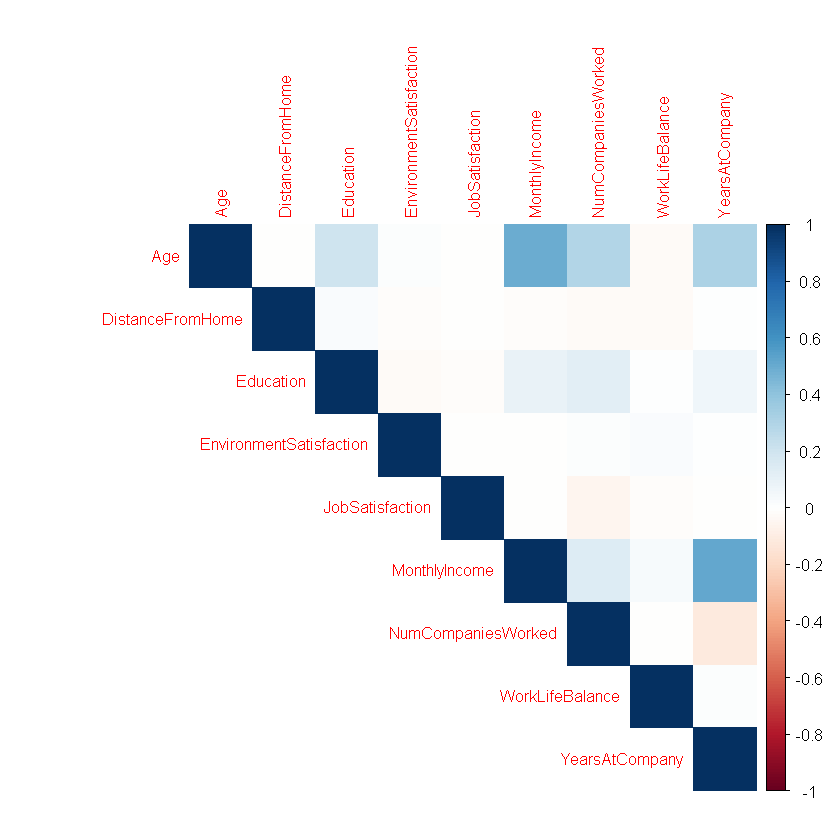

In [11]:
corr_matrix <- cor(num_data)

corrplot(corr_matrix,
         method = "color",
         type = "upper",
         tl.cex = 0.8)

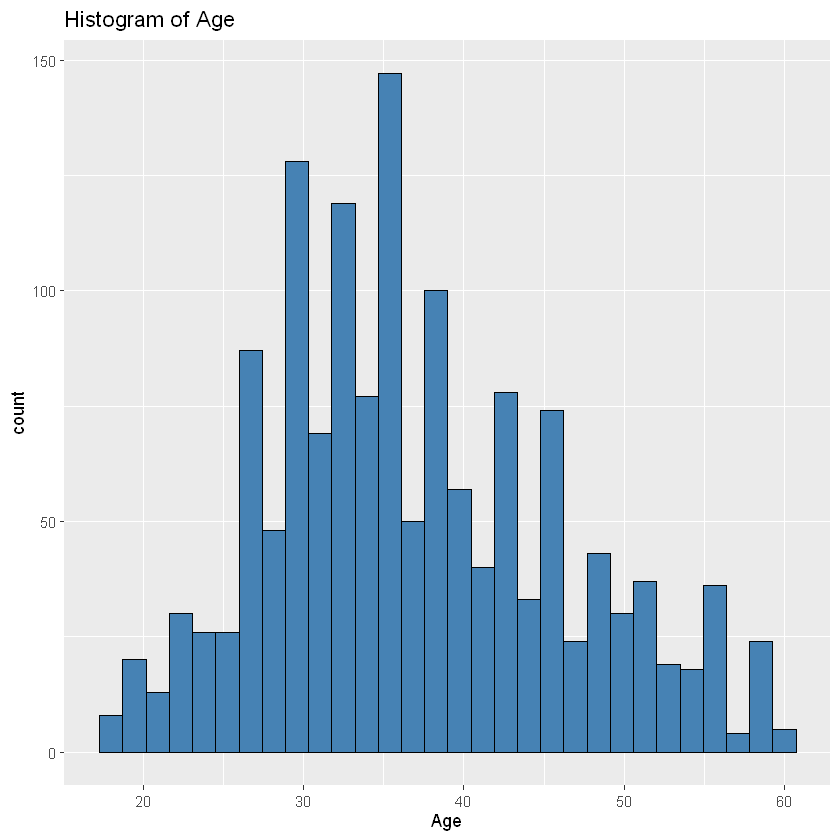

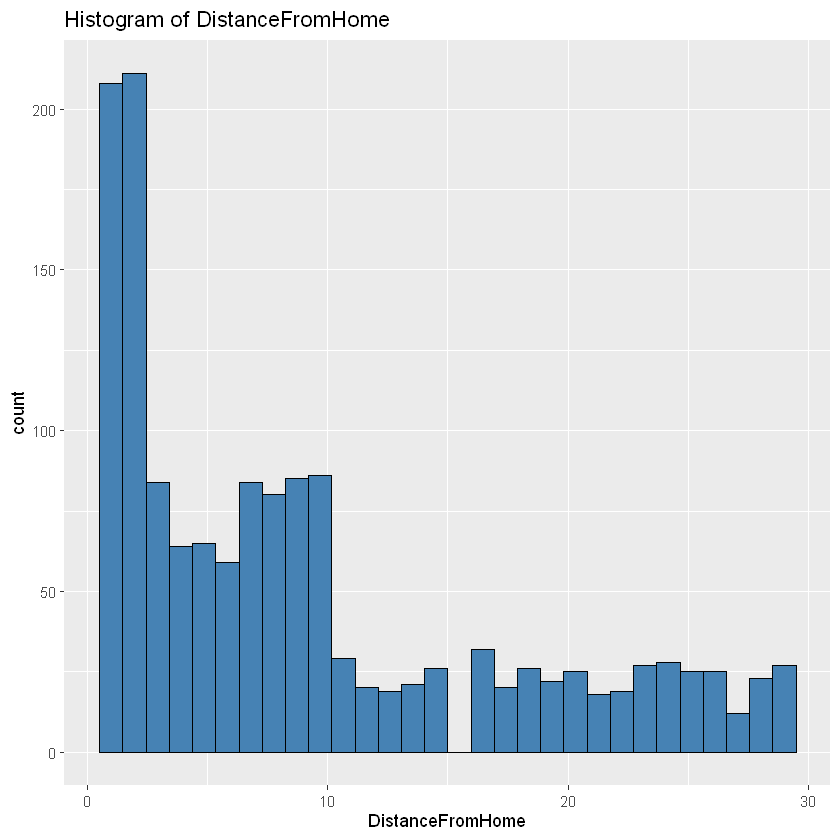

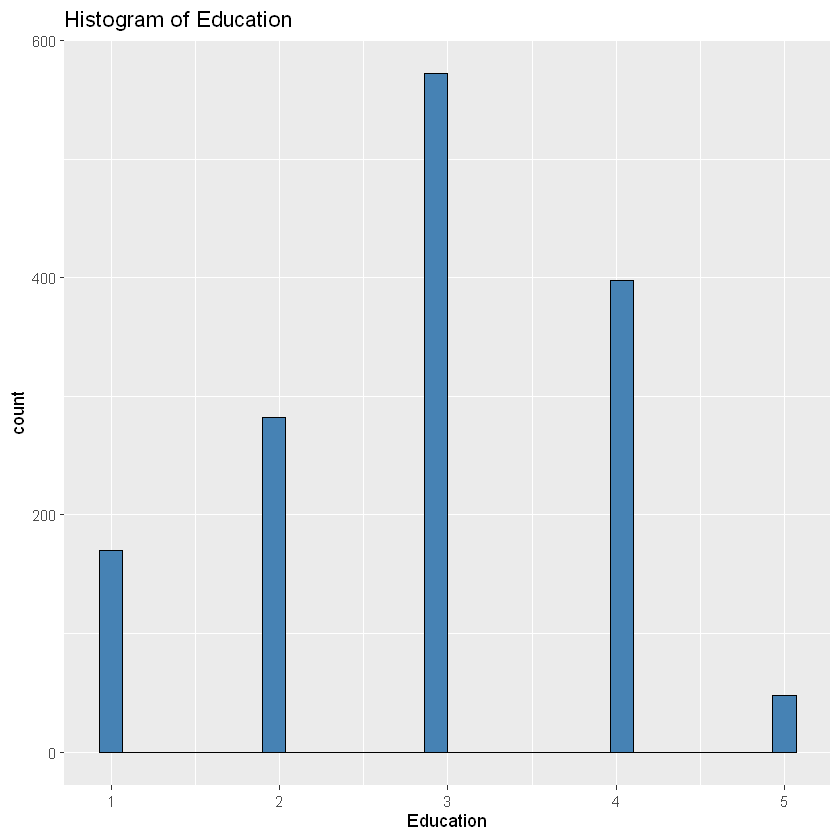

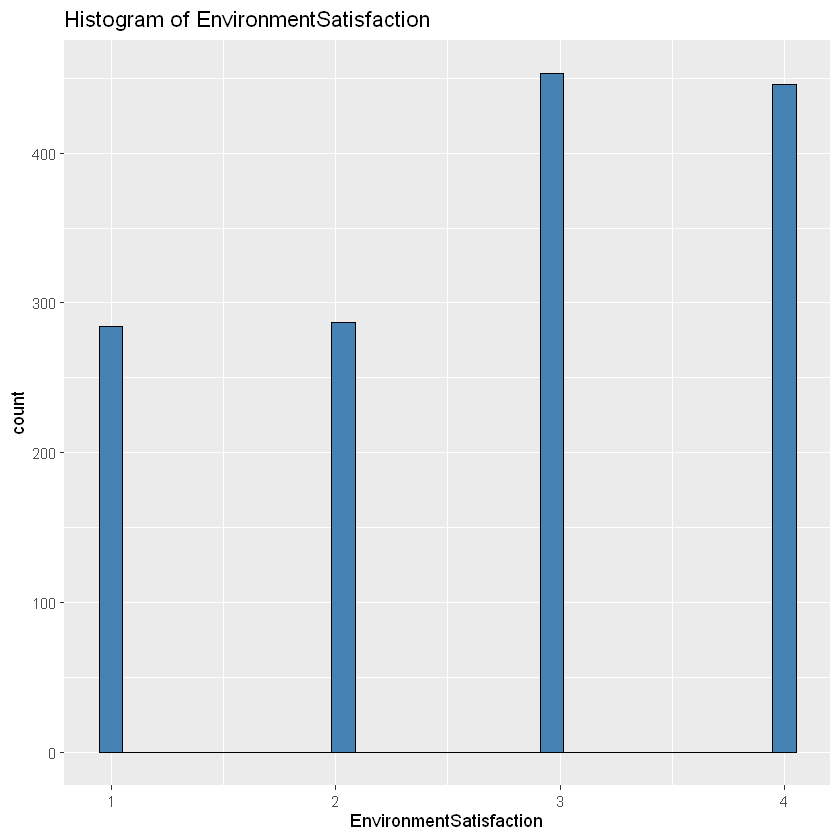

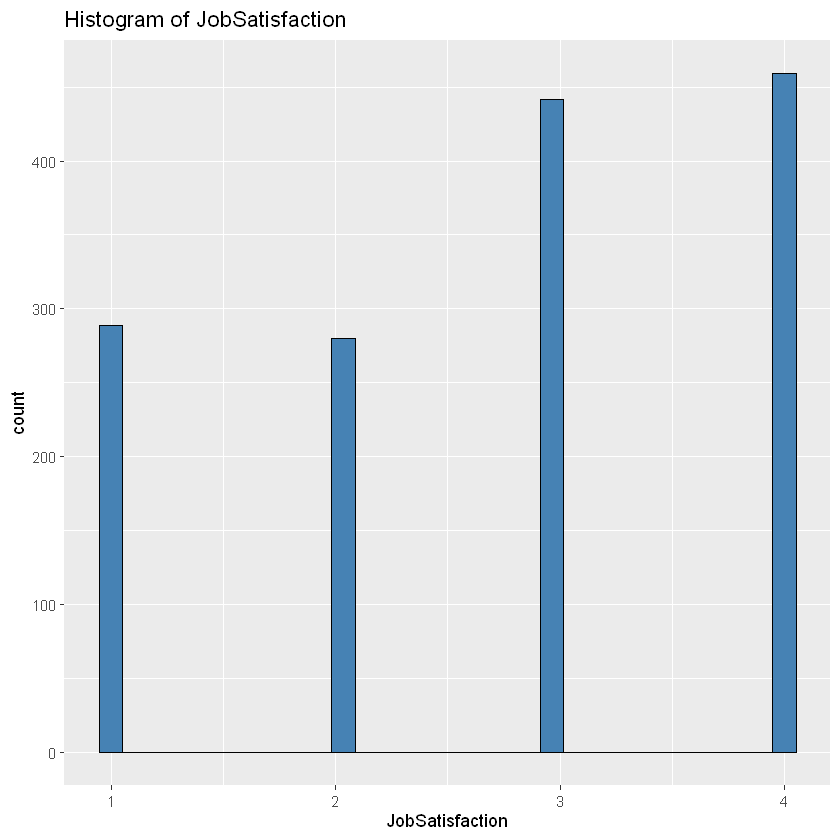

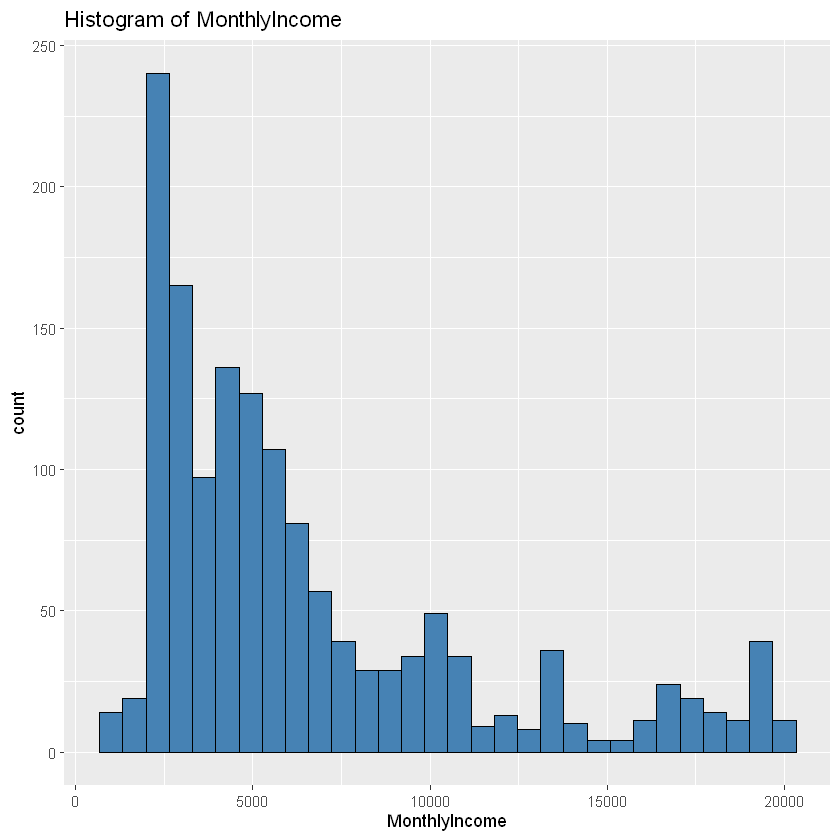

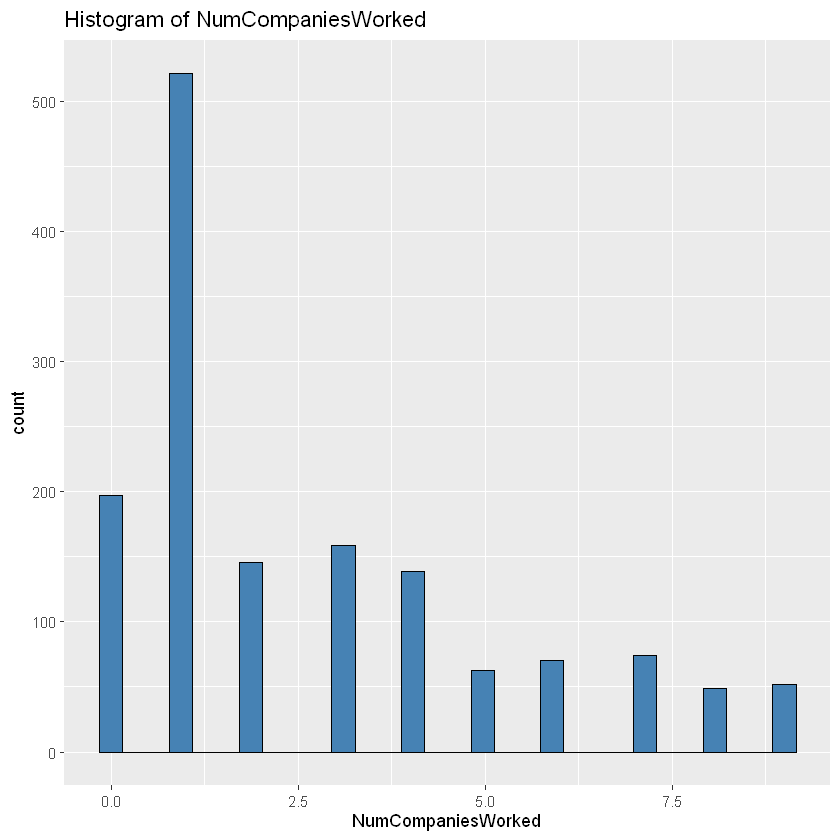

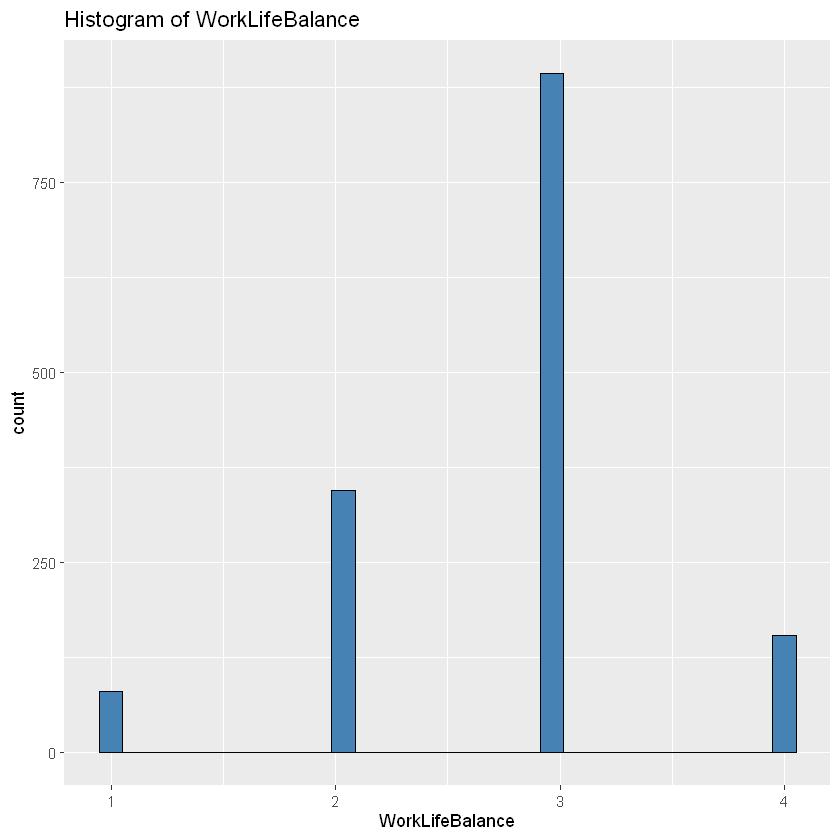

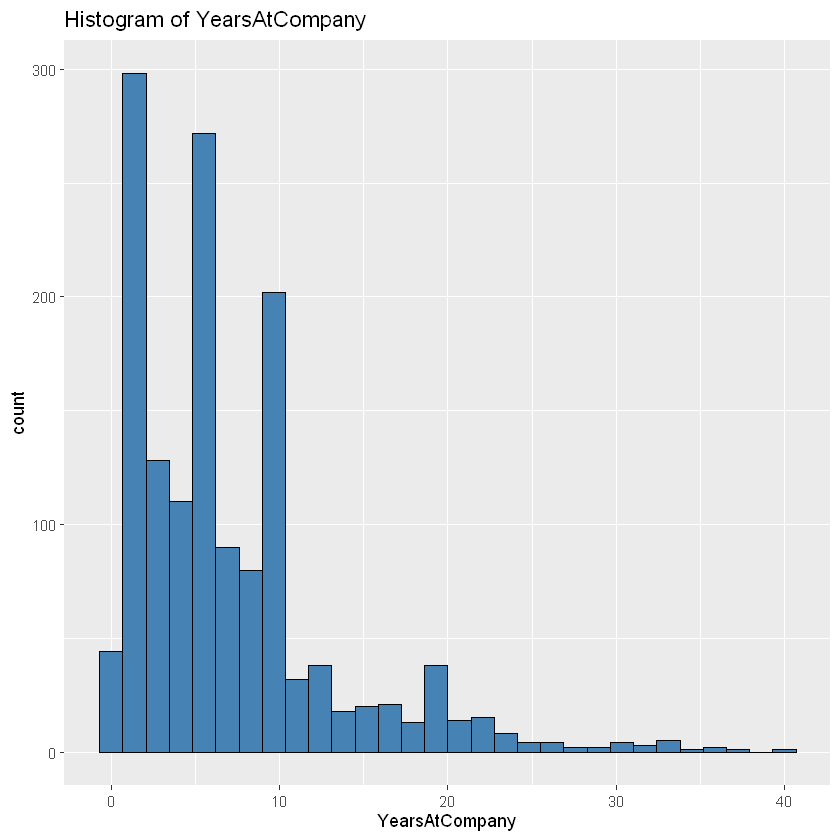

In [12]:
numeric_cols <- names(num_data)

for(col in numeric_cols){
  print(
    ggplot(data, aes(x = .data[[col]])) +
      geom_histogram(bins = 30,
                     fill = "steelblue",
                     color = "black") +
      labs(title = paste("Histogram of", col))
  )
}

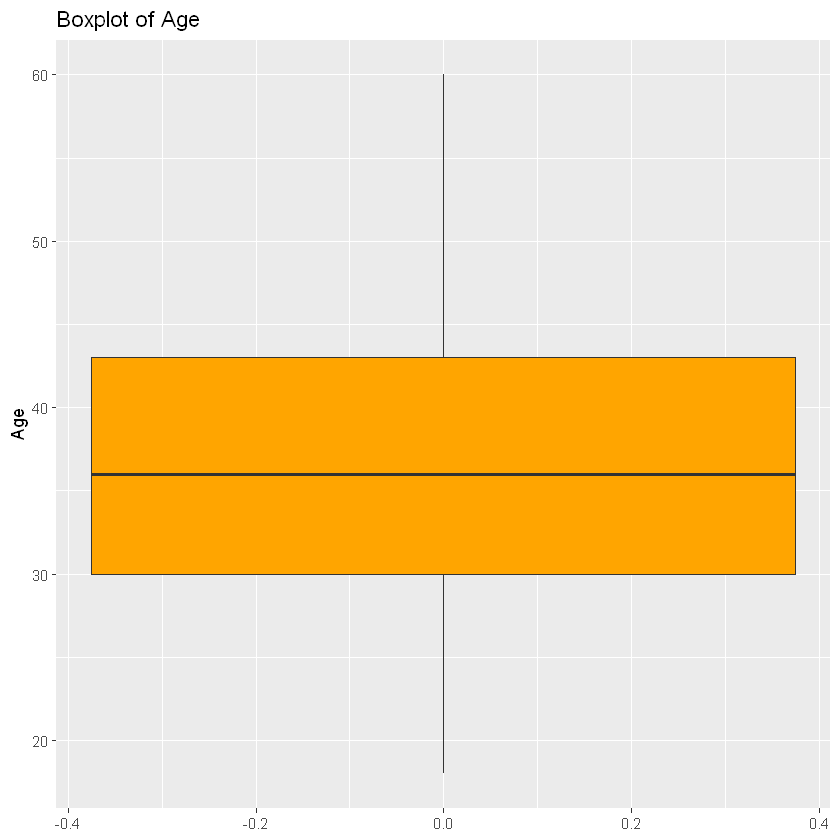

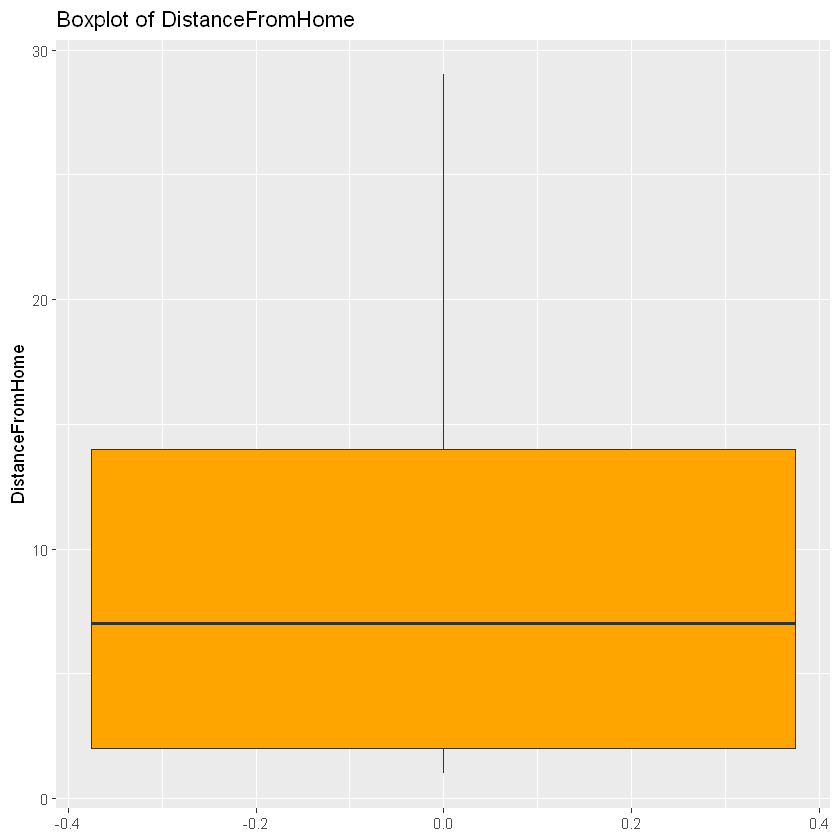

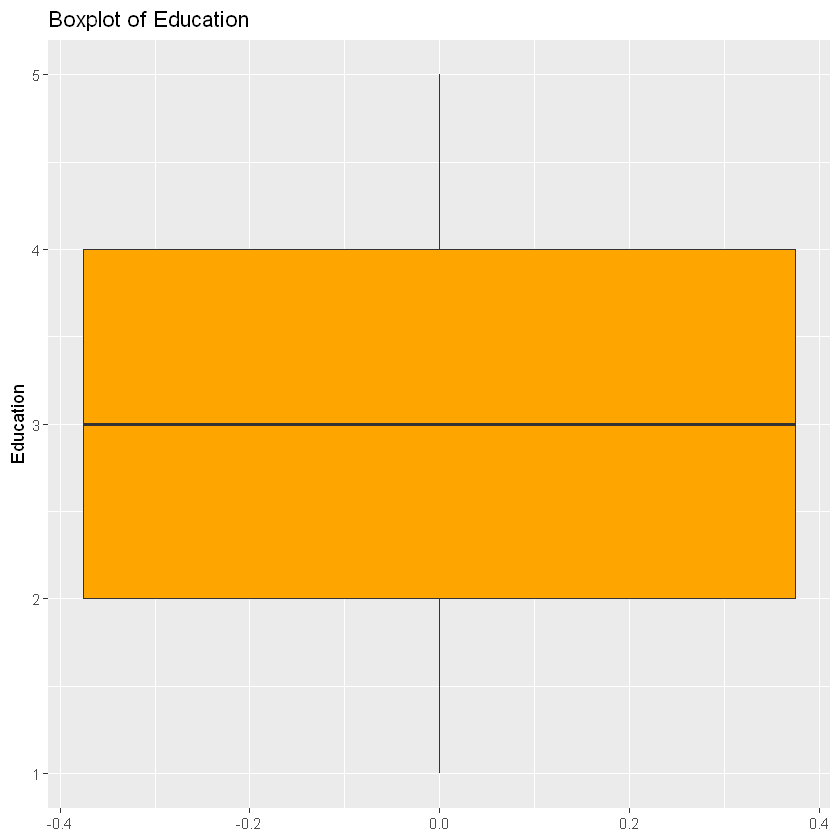

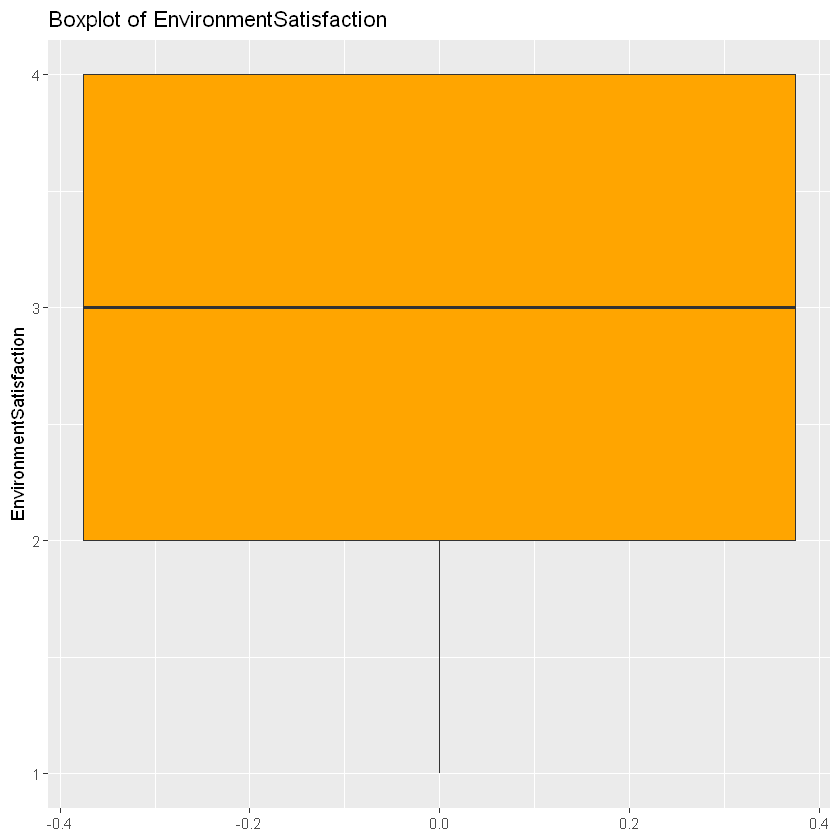

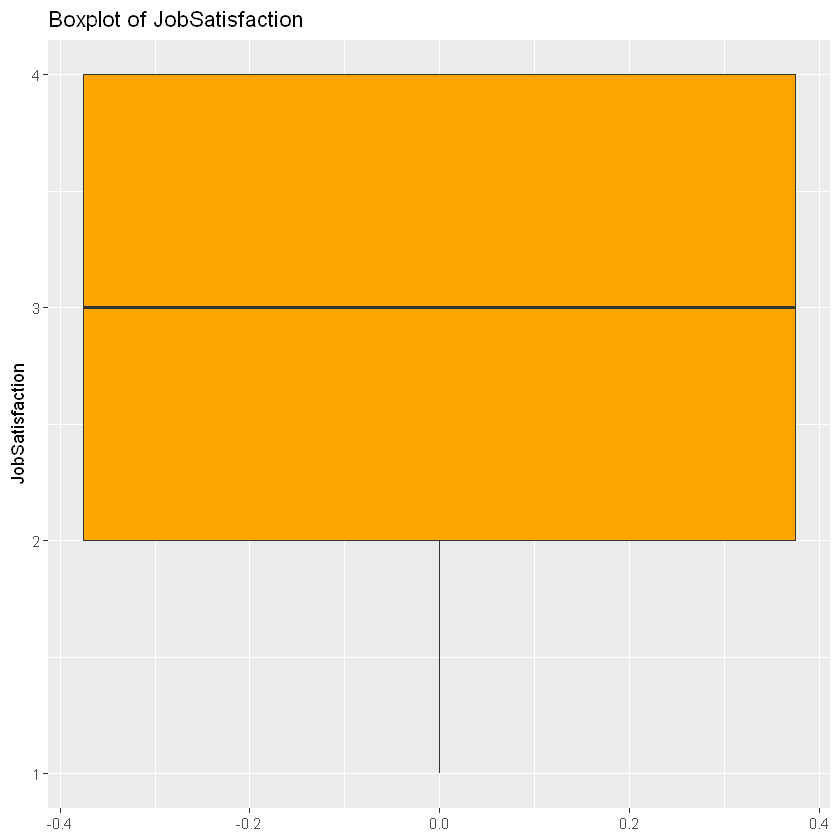

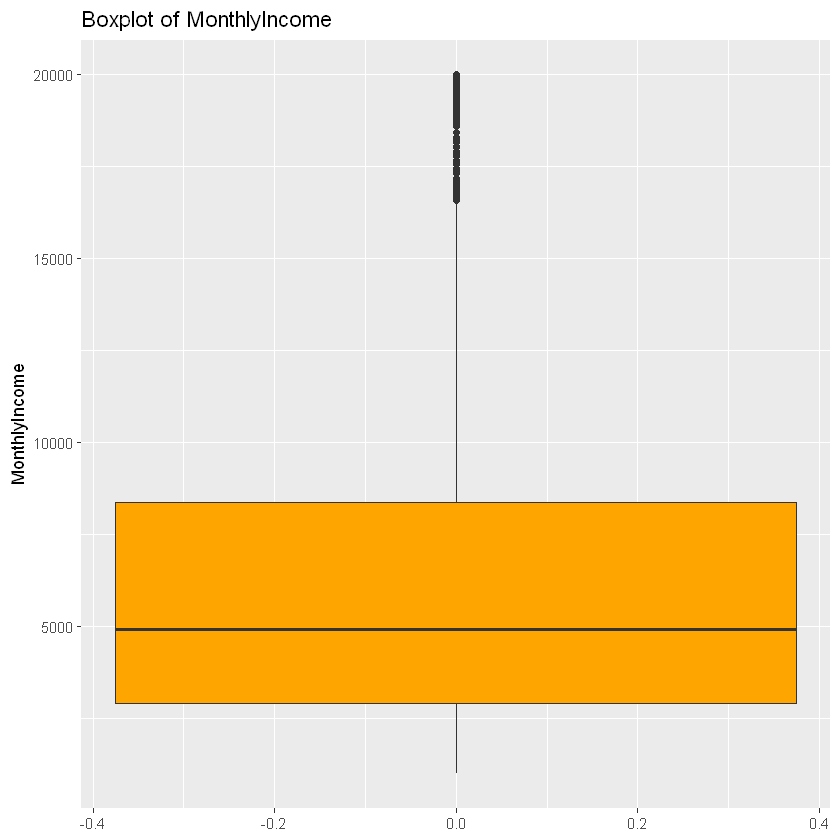

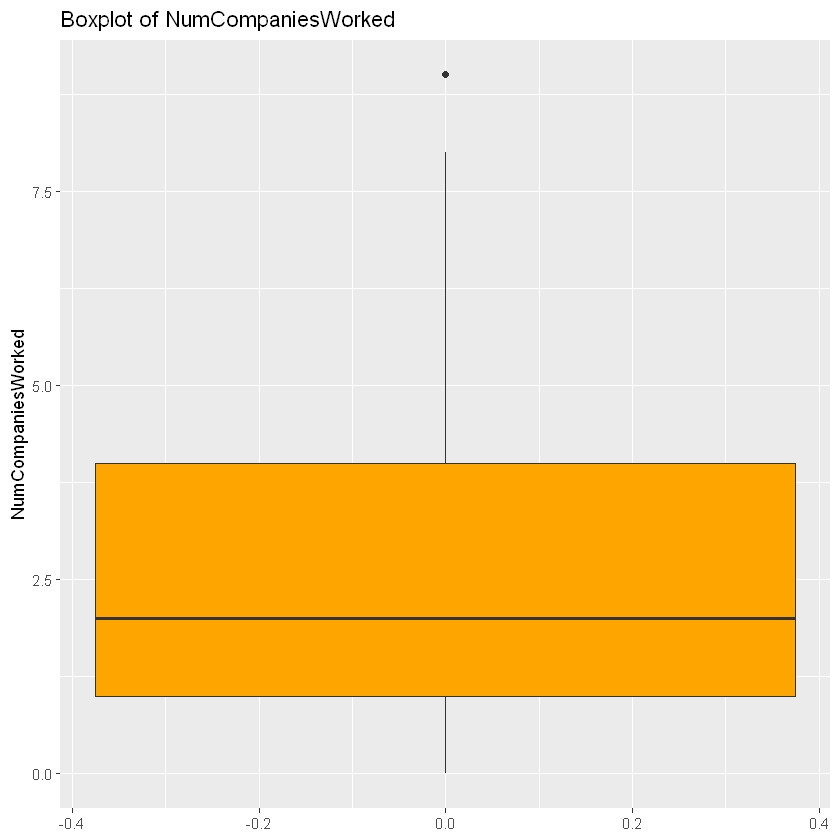

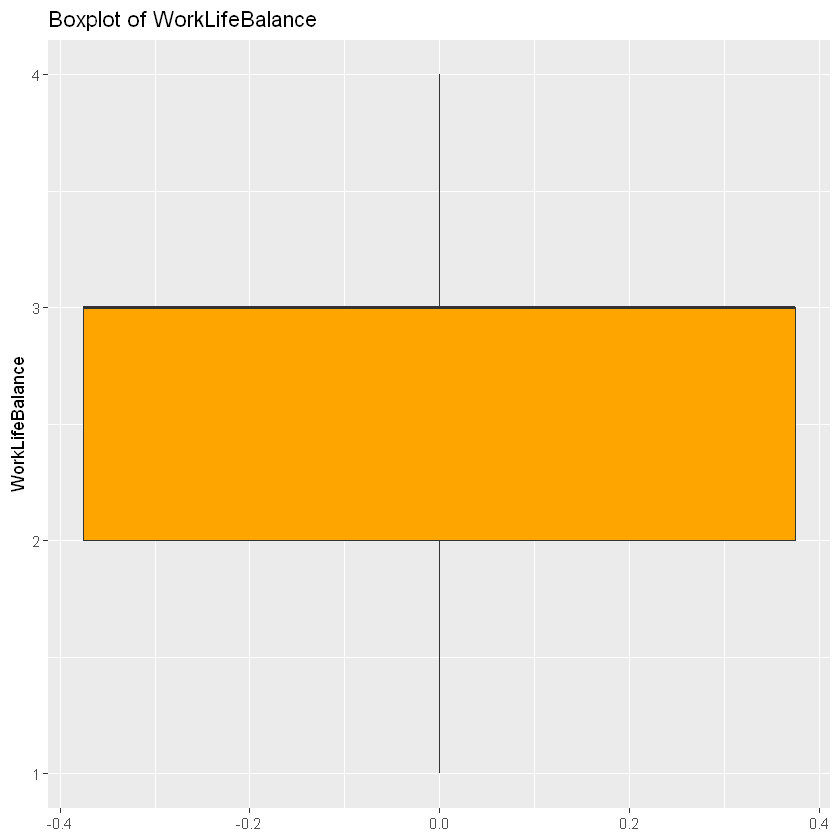

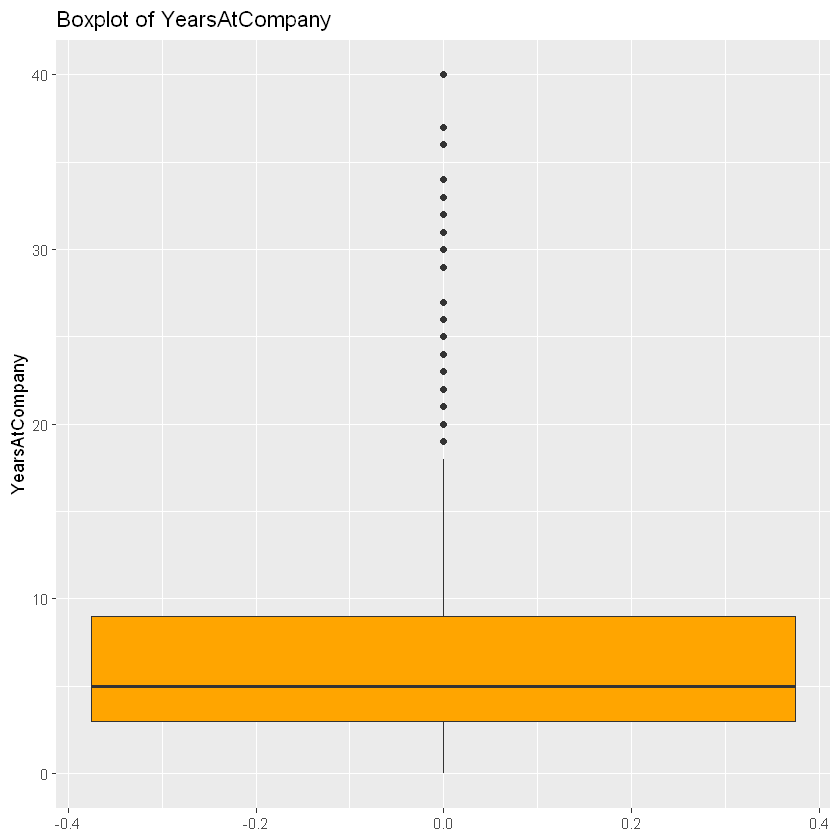

In [13]:
for(col in numeric_cols){
  print(
    ggplot(data, aes(y = .data[[col]])) +
      geom_boxplot(fill = "orange") +
      labs(title = paste("Boxplot of", col))
  )
}

In [14]:
categorical_cols <- names(data %>%
                            select(where(is.character)))

categorical_cols

[1] "Attrition"      "Department"     "EducationField" "MaritalStatus"

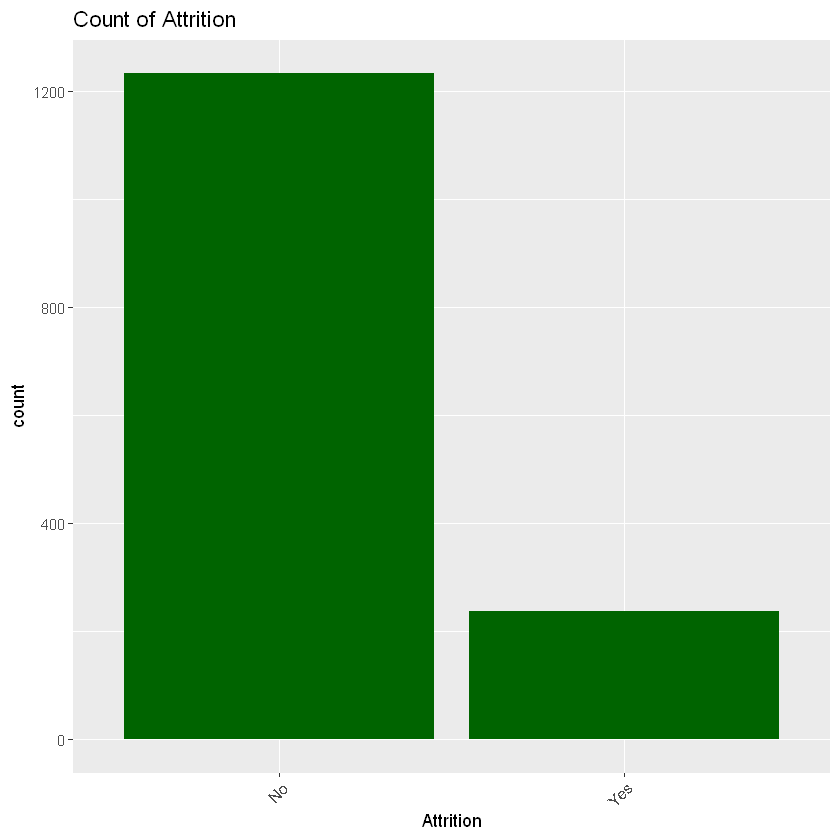

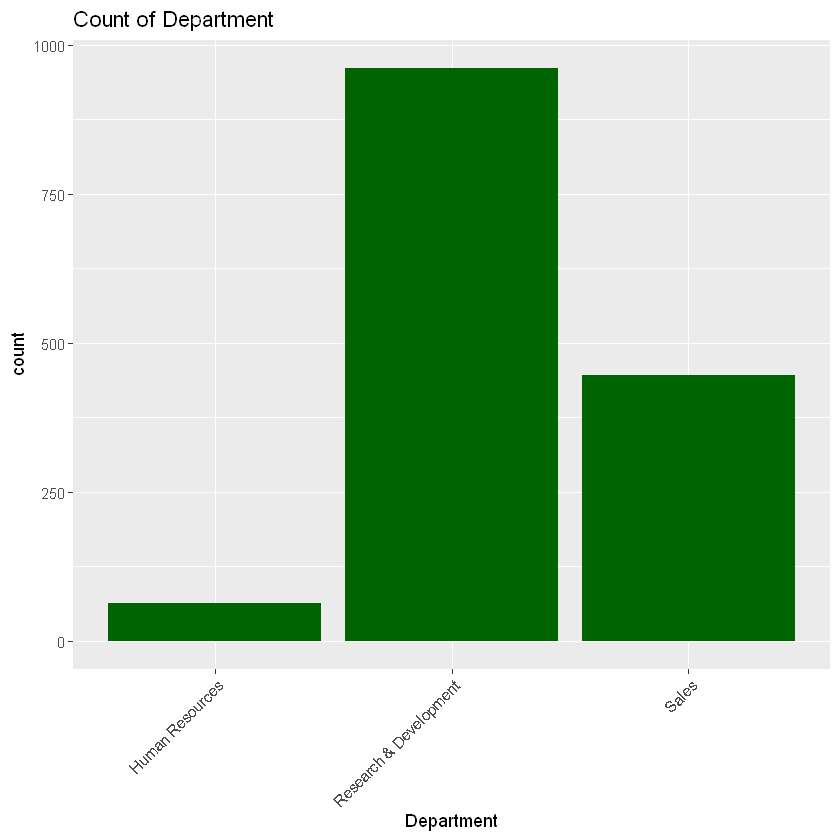

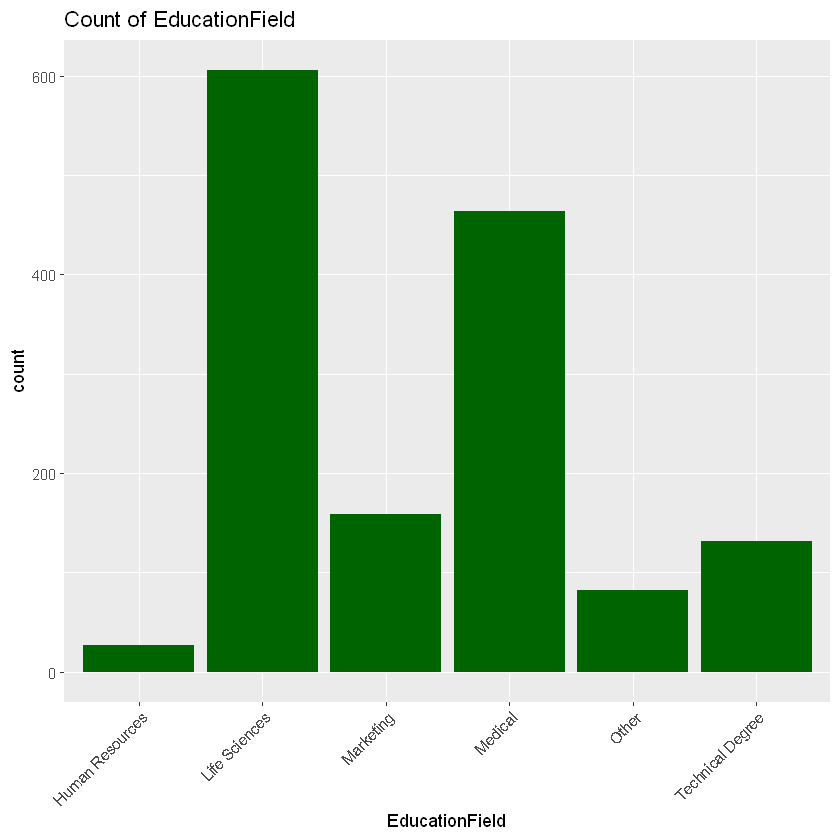

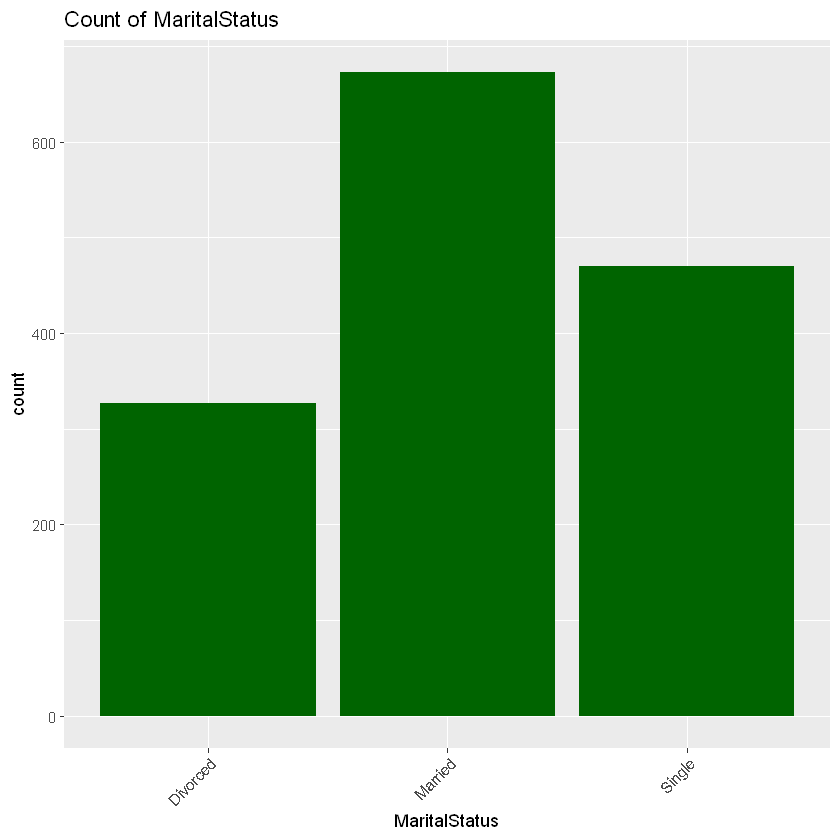

In [15]:
for(col in categorical_cols){
  print(
    ggplot(data,
           aes(x = .data[[col]])) +
      geom_bar(fill = "darkgreen") +
      labs(title = paste("Count of", col)) +
      theme(axis.text.x = element_text(angle = 45,
                                       hjust = 1))
  )
}

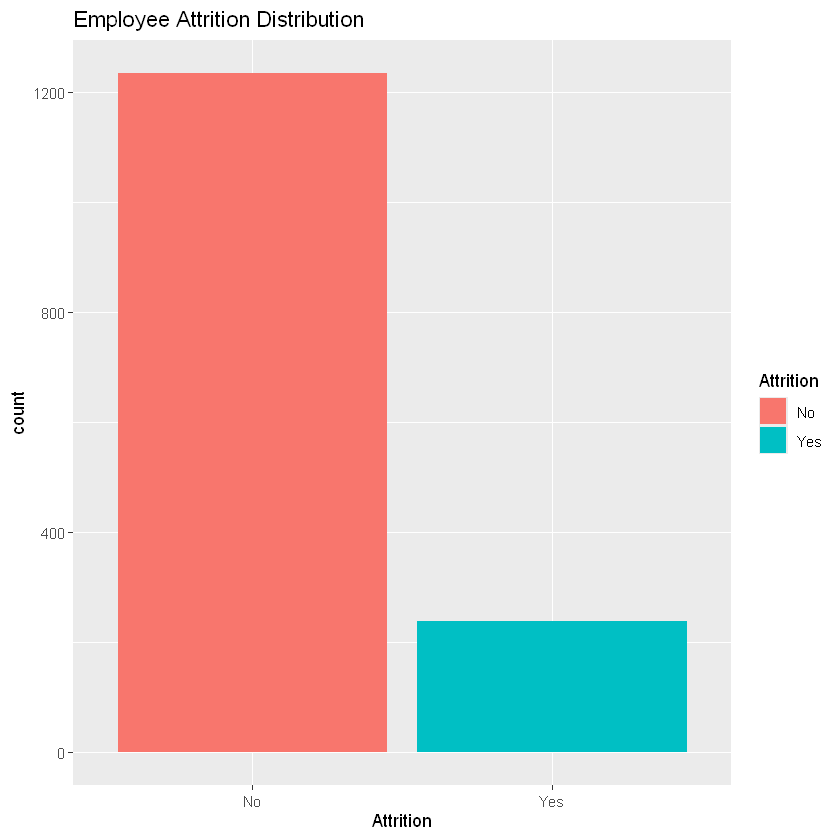

In [16]:
ggplot(data,
       aes(x = Attrition,
           fill = Attrition)) +
  geom_bar() +
  labs(title = "Employee Attrition Distribution")

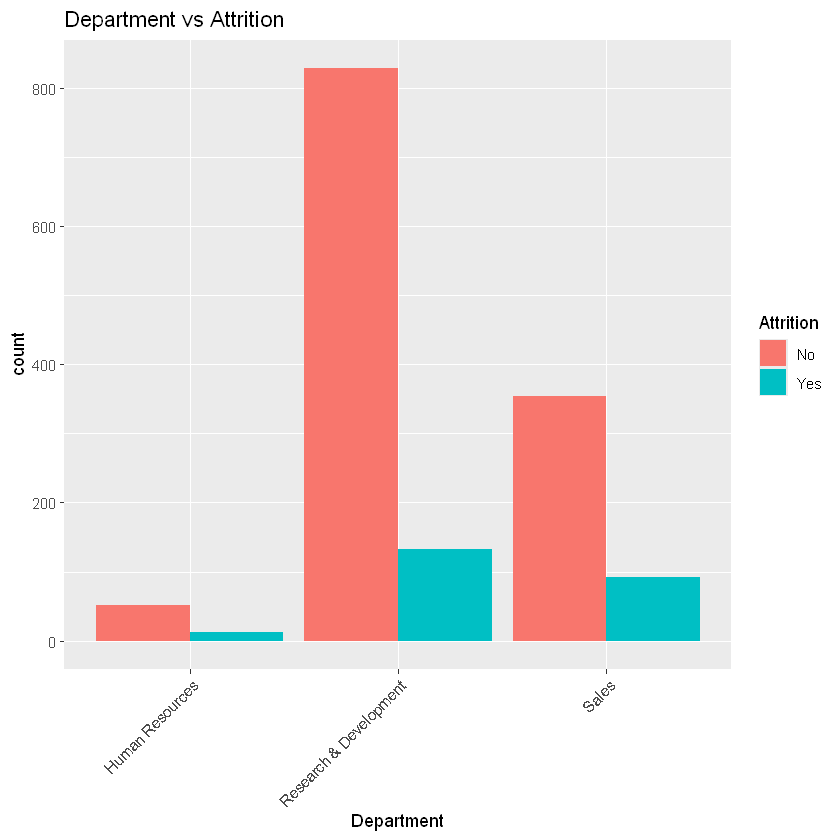

In [17]:
ggplot(data,
       aes(x = Department,
           fill = Attrition)) +
  geom_bar(position = "dodge") +
  labs(title = "Department vs Attrition") +
  theme(axis.text.x = element_text(angle = 45,
                                   hjust = 1))

`geom_smooth()` using formula = 'y ~ x'


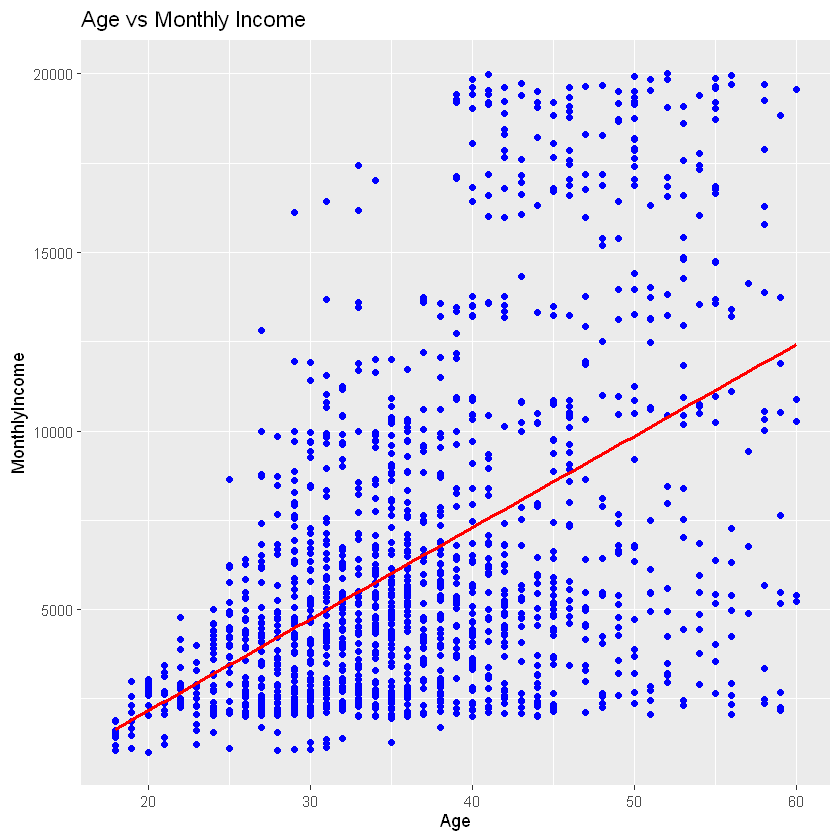

In [18]:
ggplot(data,
       aes(x = Age,
           y = MonthlyIncome)) +
  geom_point(color = "blue") +
  geom_smooth(method = "lm",
              se = FALSE,
              color = "red") +
  labs(title = "Age vs Monthly Income")

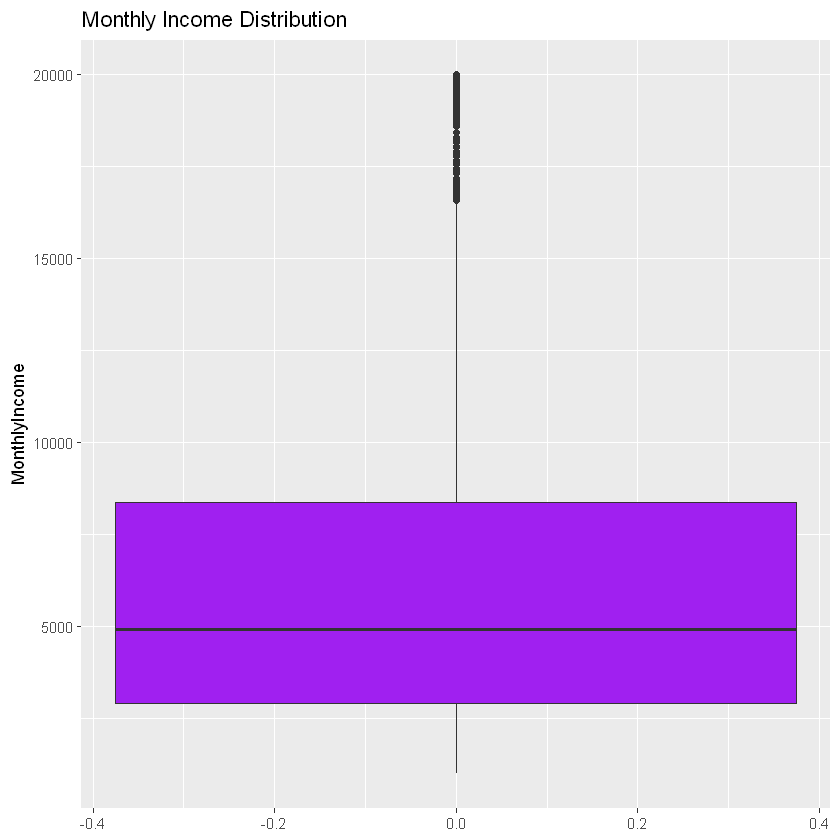

In [19]:
ggplot(data,
       aes(y = MonthlyIncome)) +
  geom_boxplot(fill = "purple") +
  labs(title = "Monthly Income Distribution")

In [20]:
table(data$Department)


       Human Resources Research & Development                  Sales 
                    63                    961                    446 

In [21]:
table(data$Department)


       Human Resources Research & Development                  Sales 
                    63                    961                    446 

In [22]:
data %>%
  group_by(Department) %>%
  summarise(
    Average_Income = mean(MonthlyIncome),
    Maximum_Income = max(MonthlyIncome),
    Minimum_Income = min(MonthlyIncome),
    Employees = n()
  )

Department,Average_Income,Maximum_Income,Minimum_Income,Employees
<chr>,<dbl>,<int>,<int>,<int>
Human Resources,6654.508,19717,1555,63
Research & Development,6281.253,19999,1009,961
Sales,6959.173,19847,1052,446


In [27]:
colnames(data)

[1] "Age"                     "Attrition"              
 [3] "Department"              "DistanceFromHome"       
 [5] "Education"               "EducationField"         
 [7] "EnvironmentSatisfaction" "JobSatisfaction"        
 [9] "MaritalStatus"           "MonthlyIncome"          
[11] "NumCompaniesWorked"      "WorkLifeBalance"        
[13] "YearsAtCompany"

In [25]:
prop.table(table(data$Attrition)) * 100


      No      Yes 
83.87755 16.12245 

In [26]:
prop.table(table(data$Attrition)) * 100


      No      Yes 
83.87755 16.12245 